# Collateral and Margining Simulation  
## Python Monte Carlo Extension

This notebook extends the Excel-based collateral and margining dashboard by implementing the model in Python and adding a Monte Carlo simulation framework.

The objective of the project is to understand how collateral mechanisms reduce counterparty risk in OTC derivatives, while also showing that margining can create liquidity pressure and may not fully eliminate losses under stressed scenarios.

In the Excel version, the model simulates one path of the underlying asset price, calculates the mark-to-market of a simplified forward contract, computes daily variation margin, estimates initial margin and analyses a counterparty default scenario during the Margin Period of Risk.

The Python version adds an important extension: instead of analysing only one simulated path, we can generate many possible market scenarios. This allows us to estimate how often the initial margin is insufficient to cover losses during the Margin Period of Risk.

The key question of this notebook is:

**Across many simulated market scenarios, how often does the initial margin fail to fully cover the loss during the Margin Period of Risk?**

The notebook will follow this structure:

1. Define the model inputs  
2. Simulate underlying asset price paths using Geometric Brownian Motion  
3. Calculate the mark-to-market of a simplified long forward contract  
4. Compute daily variation margin  
5. Estimate initial margin using a parametric VaR-style approach  
6. Simulate a counterparty default scenario  
7. Run a Monte Carlo simulation across many paths  
8. Estimate the probability of uncovered loss  
9. Visualise the distribution of losses and margin outcomes  
10. Summarise the main insights and limitations  

This is a simplified educational model. It does not include discounting, netting sets, collateral thresholds, minimum transfer amounts, funding costs, wrong-way risk, legal close-out mechanics or a full SIMM implementation. The aim is to make the core mechanics of collateral, variation margin, initial margin and default exposure transparent and intuitive.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

# Display settings
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Model Inputs

This section defines the main assumptions used in the simulation. These inputs are aligned with the Excel version of the project and describe the market environment, the derivative position and the margining framework.

The key inputs include the initial underlying price, annual volatility, annual drift, trading days per year, notional amount, forward strike, confidence level, Margin Period of Risk and default day.

In [ ]:
# Market assumptions
S0 = 100.0                 # Initial underlying price
annual_volatility = 0.20   # Annual volatility
annual_drift = 0.00        # Annual drift
trading_days = 252         # Trading days per year

# Simulation assumptions
simulation_days = 252      # One trading year
dt = 1 / trading_days      # Daily time step

# Derivative assumptions
notional = 1_000_000       # Notional amount of the forward contract
forward_strike = 100.0     # Forward strike price

# Margining assumptions
confidence_level = 0.99    # Confidence level for initial margin
mpor = 10                  # Margin Period of Risk in days
default_day = 180          # Counterparty default day

# Monte Carlo assumptions
n_simulations = 10_000     # Number of simulated paths

In [ ]:
inputs = pd.DataFrame({"Input": ["Initial underlying price", "Annual volatility", "Annual drift", "Trading days per year", "Simulation days", "Notional", "Forward strike", "Confidence level", "Margin Period of Risk", "Default day", "Number of simulations"], "Value": [S0, annual_volatility, annual_drift, trading_days, simulation_days, notional, forward_strike, confidence_level, mpor, default_day, n_simulations]});
inputs

,Input,Value
0,Initial underlying price,100.00
1,Annual volatility,0.20
2,Annual drift,0.00
3,Trading days per year,252.00
4,Simulation days,252.00
5,Notional,"1,000,000.00"
6,Forward strike,100.00
7,Confidence level,0.99
8,Margin Period of Risk,10.00
9,Default day,180.00


## 3. Simulating One Underlying Price Path

Before running the full Monte Carlo simulation, we first simulate one underlying asset price path. This mirrors the Excel version of the project and helps verify that the Python implementation follows the same logic.

The underlying asset is simulated using Geometric Brownian Motion:

$$
S_{t+1} = S_t \times \exp\left((\mu - 0.5\sigma^2)\Delta t + \sigma\sqrt{\Delta t}Z_t\right)
$$

where:

- $S_t$ is the underlying asset price at time $t$
- $\mu$ is the annual drift
- $\sigma$ is the annual volatility
- $\Delta t$ is the daily time step
- $Z_t$ is a standard normal random shock

In [ ]:
# Simulate one underlying price path
days = np.arange(simulation_days + 1)
random_shocks = np.random.normal(0, 1, simulation_days)
daily_returns = (annual_drift - 0.5 * annual_volatility**2) * dt + annual_volatility * np.sqrt(dt) * random_shocks

underlying_prices = np.empty(simulation_days + 1)
underlying_prices[0] = S0
underlying_prices[1:] = S0 * np.exp(np.cumsum(daily_returns))

single_path = pd.DataFrame({"Day": days, "Random Shock": np.insert(random_shocks, 0, np.nan), "Daily Return": np.insert(daily_returns, 0, np.nan), "Underlying Price": underlying_prices})

single_path.head(10)

,Day,Random Shock,Daily Return,Underlying Price
0,0,NaN,NaN,100.00
1,1,2.12,0.03,102.70
2,2,1.03,0.01,104.04
3,3,-1.52,-0.02,102.06
4,4,-0.48,-0.01,101.43
5,5,1.27,0.02,103.05
6,6,-0.71,-0.01,102.13
7,7,0.44,0.01,102.69
8,8,0.77,0.01,103.69
9,9,-0.93,-0.01,102.48


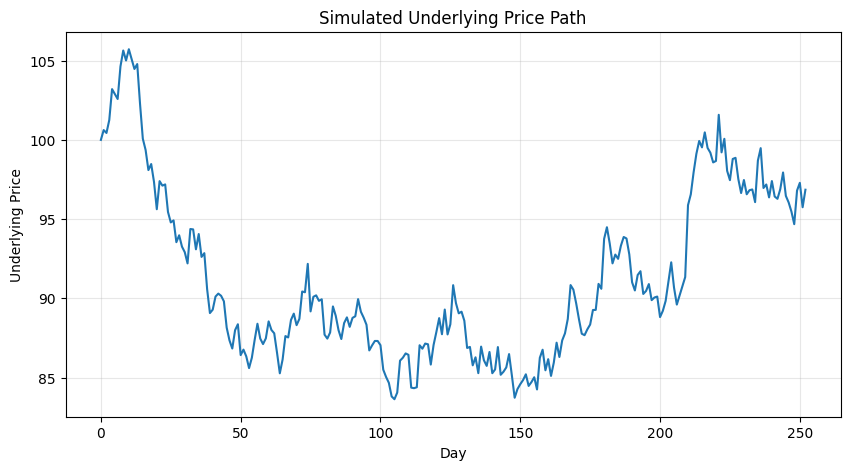

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(single_path["Day"], single_path["Underlying Price"])
plt.title("Simulated Underlying Price Path")
plt.xlabel("Day")
plt.ylabel("Underlying Price")
plt.grid(True, alpha=0.3)
plt.show()

### Multiple Simulated Price Paths

The previous chart shows one possible evolution of the underlying asset price. However, the main advantage of using Python is that we can simulate many possible market scenarios.

The chart below shows several simulated price paths. Each path represents one possible future evolution of the underlying asset under the same model assumptions.

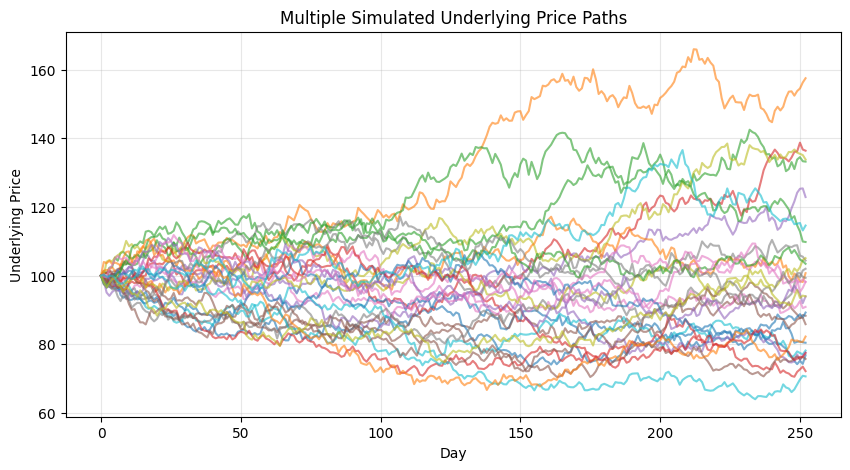

In [ ]:
# Simulate multiple underlying price paths for visualisation
n_paths_visual = 30
random_shocks_multi = np.random.normal(0, 1, (n_paths_visual, simulation_days))
daily_returns_multi = (annual_drift - 0.5 * annual_volatility**2) * dt + annual_volatility * np.sqrt(dt) * random_shocks_multi

price_paths_visual = np.empty((n_paths_visual, simulation_days + 1))
price_paths_visual[:, 0] = S0
price_paths_visual[:, 1:] = S0 * np.exp(np.cumsum(daily_returns_multi, axis=1))

plt.figure(figsize=(10, 5))
for i in range(n_paths_visual):
    plt.plot(days, price_paths_visual[i], alpha=0.6)

plt.title("Multiple Simulated Underlying Price Paths")
plt.xlabel("Day")
plt.ylabel("Underlying Price")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Mark-to-Market and Variation Margin

Once the underlying price path has been simulated, the next step is to calculate the value of the derivative. In this simplified project, the derivative is a long forward contract.

The mark-to-market value of the forward is calculated as:

$$
MTM_t = \frac{S_t - K}{K} \times Notional
$$

where:

- $S_t$ is the underlying asset price at time $t$
- $K$ is the forward strike
- $Notional$ is the size of the derivative exposure

Variation margin is calculated as the daily change in the mark-to-market value:

$$
VM_t = MTM_t - MTM_{t-1}
$$

If the mark-to-market increases, collateral is received. If the mark-to-market decreases, collateral must be posted.

In [ ]:
# Calculate mark-to-market and variation margin for the single path
single_path["Mark-to-Market"] = ((single_path["Underlying Price"] - forward_strike) / forward_strike) * notional
single_path["Variation Margin"] = single_path["Mark-to-Market"].diff().fillna(0)
single_path["Cumulative VM"] = single_path["Variation Margin"].cumsum()

single_path.head(10)

,Day,Random Shock,Daily Return,Underlying Price,Mark-to-Market,Variation Margin,Cumulative VM
0,0,NaN,NaN,100.00,0.00,0.00,0.00
1,1,2.12,0.03,102.70,"27,015.77","27,015.77","27,015.77"
2,2,1.03,0.01,104.04,"40,379.72","13,363.95","40,379.72"
3,3,-1.52,-0.02,102.06,"20,572.90","-19,806.82","20,572.90"
4,4,-0.48,-0.01,101.43,"14,285.07","-6,287.83","14,285.07"
5,5,1.27,0.02,103.05,"30,522.76","16,237.70","30,522.76"
6,6,-0.71,-0.01,102.13,"21,294.61","-9,228.15","21,294.61"
7,7,0.44,0.01,102.69,"26,939.77","5,645.16","26,939.77"
8,8,0.77,0.01,103.69,"36,928.93","9,989.16","36,928.93"
9,9,-0.93,-0.01,102.48,"24,808.53","-12,120.39","24,808.53"


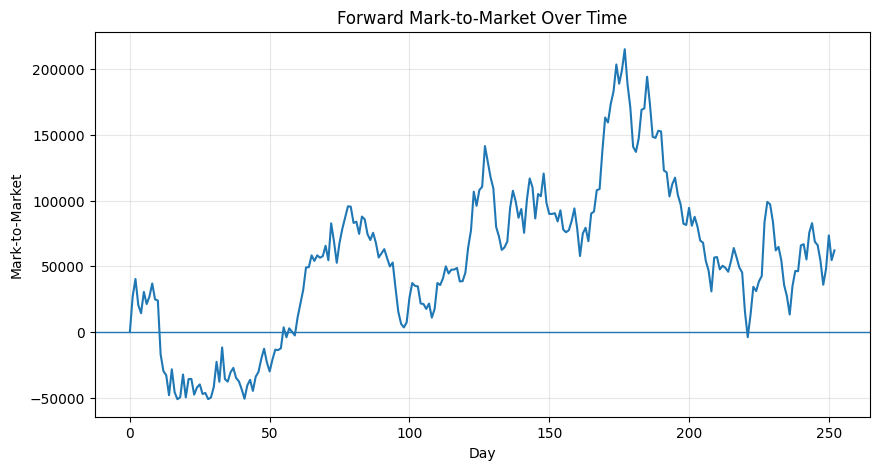

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(single_path["Day"], single_path["Mark-to-Market"])
plt.axhline(0, linewidth=1)
plt.title("Forward Mark-to-Market Over Time")
plt.xlabel("Day")
plt.ylabel("Mark-to-Market")
plt.grid(True, alpha=0.3)
plt.show()

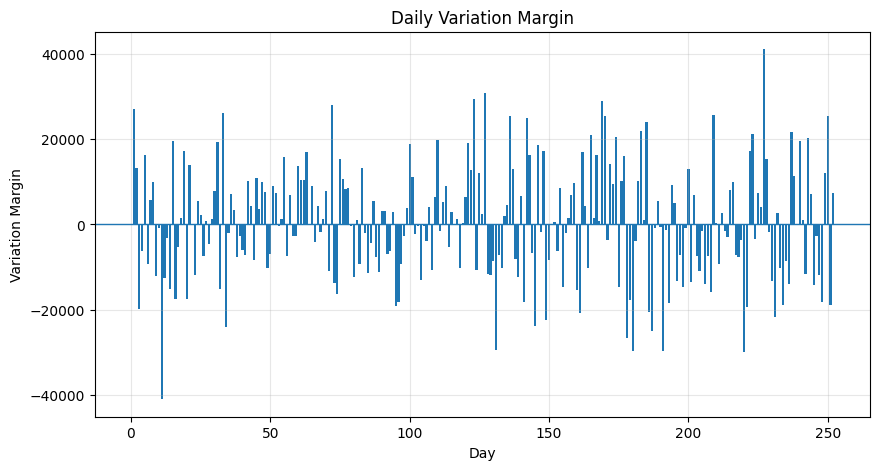

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(single_path["Day"], single_path["Variation Margin"])
plt.axhline(0, linewidth=1)
plt.title("Daily Variation Margin")
plt.xlabel("Day")
plt.ylabel("Variation Margin")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
single_path[["Day", "Mark-to-Market", "Variation Margin", "Cumulative VM"]].tail()

,Day,Mark-to-Market,Variation Margin,Cumulative VM
248,248,"35,977.97","-18,290.24","35,977.97"
249,249,"48,054.15","12,076.18","48,054.15"
250,250,"73,487.05","25,432.90","73,487.05"
251,251,"54,653.86","-18,833.19","54,653.86"
252,252,"62,076.55","7,422.69","62,076.55"


## 5. Initial Margin Calculation

Variation margin adjusts collateral daily based on changes in the mark-to-market value of the derivative. However, if the counterparty defaults, the position may not be closed or replaced immediately.

The period between the counterparty default and the close-out or replacement of the position is called the Margin Period of Risk (MPoR). Initial margin acts as a collateral buffer designed to cover potential losses during this period.

In this simplified model, initial margin is estimated using a parametric VaR-style approach:

`IM = z(confidence level) × daily MTM volatility × sqrt(MPoR)`

where:

- `z(confidence level)` is the normal quantile corresponding to the chosen confidence level
- `daily MTM volatility` is the standard deviation of daily mark-to-market changes
- `MPoR` is the Margin Period of Risk in days

In [ ]:
from scipy.stats import norm

# Initial margin calculation
daily_mtm_volatility = single_path["Variation Margin"].std()
z_score = norm.ppf(confidence_level)
initial_margin = z_score * daily_mtm_volatility * np.sqrt(mpor)

initial_margin_summary = pd.DataFrame({"Metric": ["Confidence Level", "Z-score", "MPoR", "Daily MTM Volatility", "Initial Margin"], "Value": [confidence_level, z_score, mpor, daily_mtm_volatility, initial_margin]})

initial_margin_summary

,Metric,Value
0,Confidence Level,0.99
1,Z-score,2.33
2,MPoR,10.00
3,Daily MTM Volatility,"13,402.30"
4,Initial Margin,"98,594.83"


The initial margin represents the estimated collateral buffer required to cover potential losses during the Margin Period of Risk. A higher confidence level, higher daily MTM volatility or longer MPoR will increase the required initial margin.

## 6. Default Scenario Analysis

This section analyses what happens if the counterparty defaults during the life of the derivative.

At the default day, the position has a certain mark-to-market value. However, the position is not assumed to be closed immediately. Instead, it is closed or replaced after the Margin Period of Risk.

The close-out day is calculated as:

`Close-out Day = Default Day + MPoR`

The loss during the Margin Period of Risk is calculated as:

`Loss during MPoR = max(MTM at Close-out - MTM at Default, 0)`

Finally, the uncovered loss is calculated as:

`Uncovered Loss = max(Loss during MPoR - Initial Margin, 0)`

The purpose of this section is to test whether the initial margin buffer is sufficient to cover the additional exposure generated after default.

In [ ]:
# Default scenario analysis for the single path
closeout_day = default_day + mpor
mtm_at_default = single_path.loc[single_path["Day"] == default_day, "Mark-to-Market"].iloc[0]
mtm_at_closeout = single_path.loc[single_path["Day"] == closeout_day, "Mark-to-Market"].iloc[0]
loss_during_mpor = max(mtm_at_closeout - mtm_at_default, 0)
uncovered_loss = max(loss_during_mpor - initial_margin, 0)

default_summary = pd.DataFrame({"Metric": ["Default Day", "MPoR", "Close-out Day", "MTM at Default", "MTM at Close-out", "Loss during MPoR", "Initial Margin", "Uncovered Loss"], "Value": [default_day, mpor, closeout_day, mtm_at_default, mtm_at_closeout, loss_during_mpor, initial_margin, uncovered_loss]})

default_summary

,Metric,Value
0,Default Day,180.00
1,MPoR,10.00
2,Close-out Day,190.00
3,MTM at Default,"140,994.68"
4,MTM at Close-out,"152,589.97"
5,Loss during MPoR,"11,595.29"
6,Initial Margin,"98,594.83"
7,Uncovered Loss,0.00


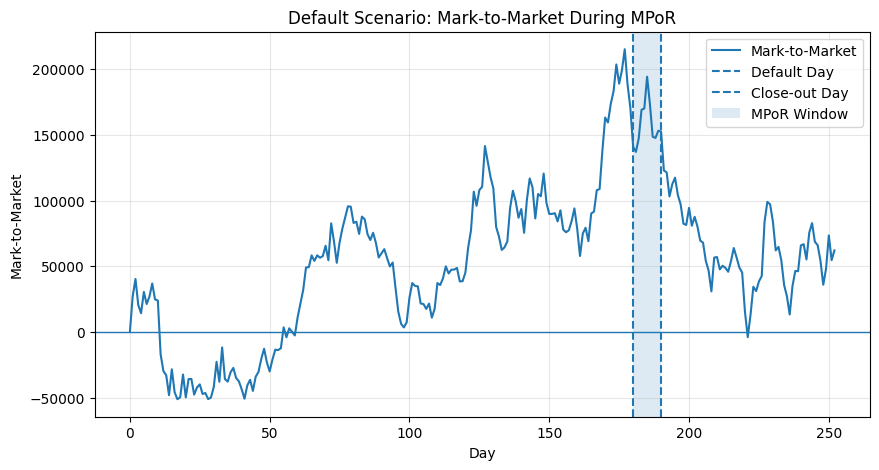

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(single_path["Day"], single_path["Mark-to-Market"], label="Mark-to-Market")
plt.axvline(default_day, linestyle="--", label="Default Day")
plt.axvline(closeout_day, linestyle="--", label="Close-out Day")
plt.axhline(0, linewidth=1)
plt.axvspan(default_day, closeout_day, alpha=0.15, label="MPoR Window")
plt.title("Default Scenario: Mark-to-Market During MPoR")
plt.xlabel("Day")
plt.ylabel("Mark-to-Market")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Monte Carlo Simulation

The previous sections analysed one simulated market path. However, one path only represents one possible future scenario.

The main advantage of using Python is that we can simulate many possible market scenarios. This allows us to estimate how often the initial margin would be insufficient to cover the loss during the Margin Period of Risk.

For each simulation, the model will:

1. Simulate an underlying asset price path  
2. Calculate the forward mark-to-market  
3. Calculate daily variation margin  
4. Estimate initial margin from daily MTM volatility  
5. Measure the loss during the Margin Period of Risk  
6. Calculate the uncovered loss  

The final objective is to estimate the probability of uncovered loss across all simulated scenarios.

In [ ]:
def run_single_simulation():
    shocks = np.random.normal(0, 1, simulation_days)
    returns = (annual_drift - 0.5 * annual_volatility**2) * dt + annual_volatility * np.sqrt(dt) * shocks

    prices = np.empty(simulation_days + 1)
    prices[0] = S0
    prices[1:] = S0 * np.exp(np.cumsum(returns))

    mtm = ((prices - forward_strike) / forward_strike) * notional
    variation_margin = np.diff(mtm, prepend=mtm[0])
    daily_mtm_vol = np.std(variation_margin, ddof=1)
    im = z_score * daily_mtm_vol * np.sqrt(mpor)

    closeout_day = default_day + mpor
    mtm_default = mtm[default_day]
    mtm_closeout = mtm[closeout_day]
    loss_mpor = max(mtm_closeout - mtm_default, 0)
    uncovered = max(loss_mpor - im, 0)

    return {"Initial Margin": im, "Loss during MPoR": loss_mpor, "Uncovered Loss": uncovered, "MTM at Default": mtm_default, "MTM at Close-out": mtm_closeout}

In [ ]:
mc_results = pd.DataFrame([run_single_simulation() for _ in range(n_simulations)])
mc_results.head()

,Initial Margin,Loss during MPoR,Uncovered Loss,MTM at Default,MTM at Close-out
0,"95,580.97",0.00,0.00,"-87,820.64","-119,600.41"
1,"92,922.02","37,735.18",0.00,"-11,480.99","26,254.19"
2,"99,975.48",0.00,0.00,"186,788.76","183,014.36"
3,"73,735.77","14,762.15",0.00,"-71,135.09","-56,372.95"
4,"102,892.34",0.00,0.00,"26,774.40","2,284.13"


In [ ]:
mc_summary = pd.DataFrame({"Metric": ["Number of simulations", "Average Initial Margin", "Average Loss during MPoR", "Average Uncovered Loss", "Probability of Uncovered Loss", "Maximum Uncovered Loss"], "Value": [n_simulations, mc_results["Initial Margin"].mean(), mc_results["Loss during MPoR"].mean(), mc_results["Uncovered Loss"].mean(), (mc_results["Uncovered Loss"] > 0).mean(), mc_results["Uncovered Loss"].max()]})

mc_summary

,Metric,Value
0,Number of simulations,"10,000.00"
1,Average Initial Margin,"92,621.28"
2,Average Loss during MPoR,"15,737.88"
3,Average Uncovered Loss,152.50
4,Probability of Uncovered Loss,0.01
5,Maximum Uncovered Loss,"72,680.42"


### Monte Carlo Results Interpretation

The Monte Carlo simulation shows that the initial margin buffer covers the loss during the Margin Period of Risk in the vast majority of scenarios.

In this run, the probability of uncovered loss is around 1%. This means that, under the model assumptions, only a small fraction of simulated scenarios generate losses during the MPoR that exceed the available initial margin.

This result is consistent with the use of a 99% confidence level in the initial margin calculation. The margin is designed to cover most adverse scenarios, but not every possible outcome. Therefore, collateral significantly reduces counterparty risk, but it does not eliminate it completely.

The maximum uncovered loss represents the most severe residual loss observed across the simulations. This highlights the importance of stress testing and scenario analysis, because extreme market movements can still produce losses beyond the collateral buffer.

## 8. Monte Carlo Visualisation

This section visualises the Monte Carlo results. The objective is to understand the distribution of losses during the Margin Period of Risk and to identify the scenarios in which the initial margin buffer is not sufficient.

The charts below show:

1. The distribution of losses during the MPoR  
2. The distribution of uncovered losses  
3. A comparison between the initial margin and the loss during the MPoR across simulations  

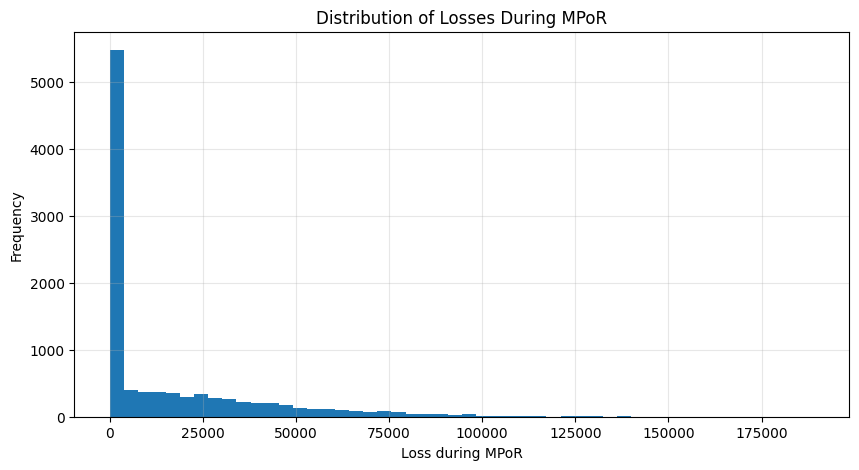

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(mc_results["Loss during MPoR"], bins=50)
plt.title("Distribution of Losses During MPoR")
plt.xlabel("Loss during MPoR")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

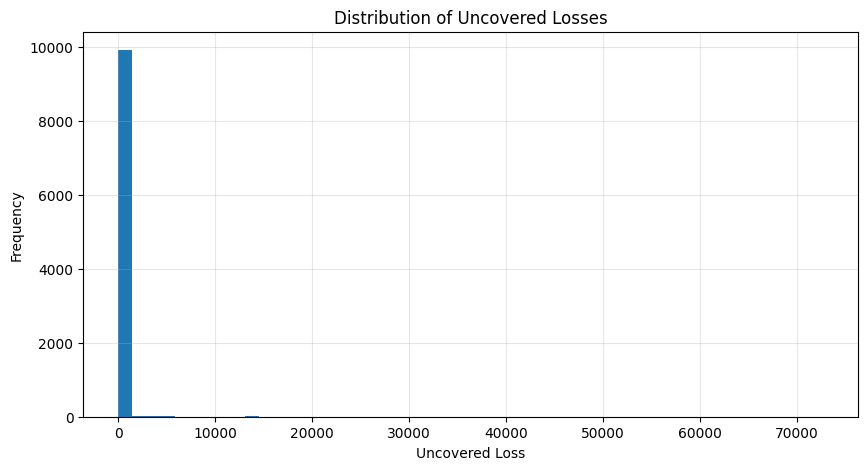

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(mc_results["Uncovered Loss"], bins=50)
plt.title("Distribution of Uncovered Losses")
plt.xlabel("Uncovered Loss")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

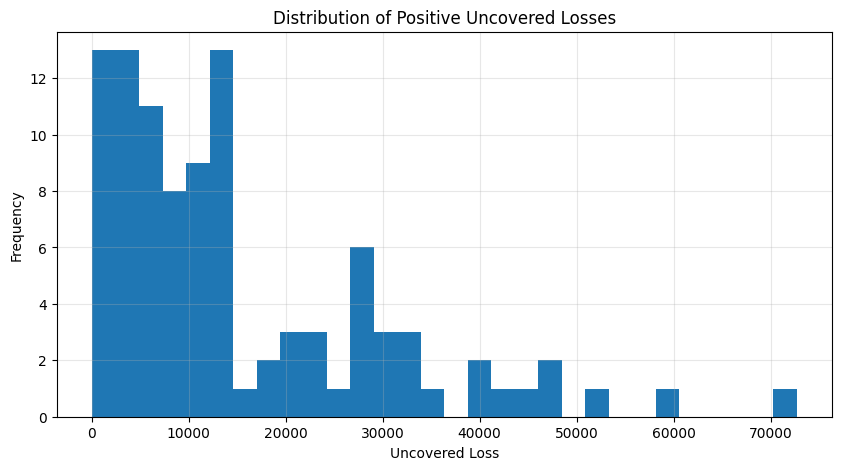

In [ ]:
uncovered_positive = mc_results[mc_results["Uncovered Loss"] > 0]

plt.figure(figsize=(10, 5))
plt.hist(uncovered_positive["Uncovered Loss"], bins=30)
plt.title("Distribution of Positive Uncovered Losses")
plt.xlabel("Uncovered Loss")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

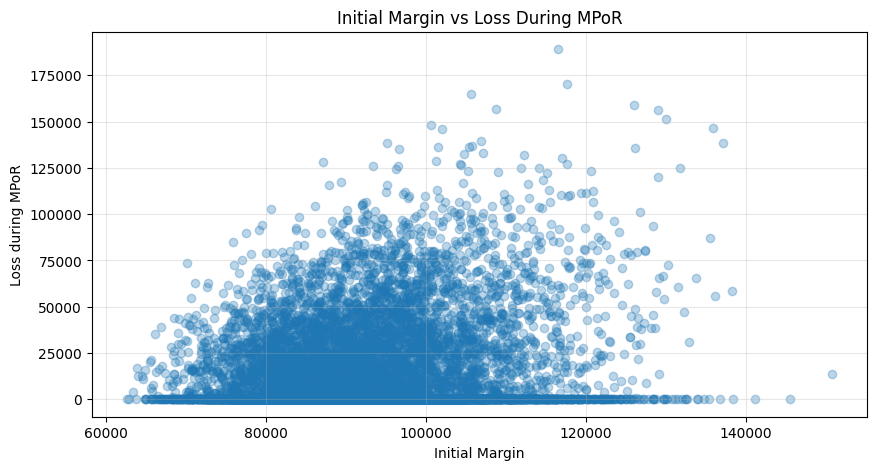

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(
    mc_results["Initial Margin"],
    mc_results["Loss during MPoR"],
    alpha=0.3
)
plt.title("Initial Margin vs Loss During MPoR")
plt.xlabel("Initial Margin")
plt.ylabel("Loss during MPoR")
plt.grid(True, alpha=0.3)
plt.show()

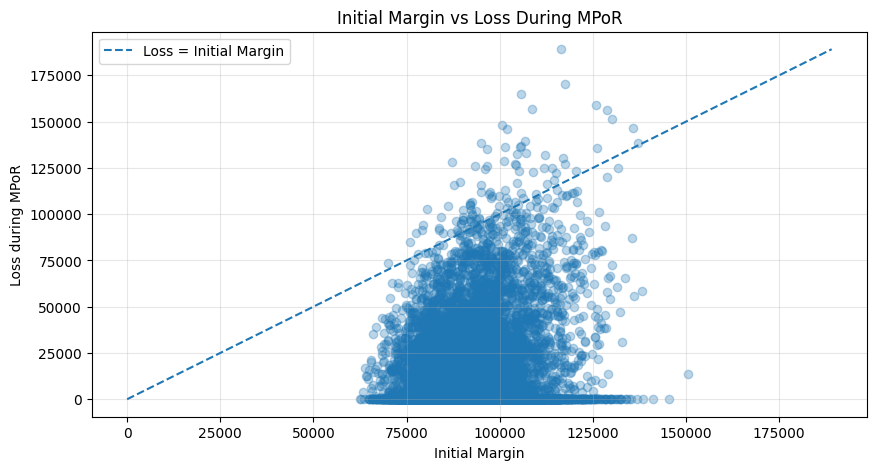

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    mc_results["Initial Margin"],
    mc_results["Loss during MPoR"],
    alpha=0.3
)

max_value = max(
    mc_results["Initial Margin"].max(),
    mc_results["Loss during MPoR"].max()
)

plt.plot([0, max_value], [0, max_value], linestyle="--", label="Loss = Initial Margin")

plt.title("Initial Margin vs Loss During MPoR")
plt.xlabel("Initial Margin")
plt.ylabel("Loss during MPoR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

En este gráfico:

puntos debajo de la línea = initial margin suficiente
puntos encima de la línea = uncovered loss



## 9. Sensitivity Analysis

The Monte Carlo simulation can also be used to analyse how margin assumptions affect the probability of uncovered loss.

This section compares different confidence levels and Margin Period of Risk assumptions. The objective is to understand the trade-off between counterparty risk reduction and collateral requirements.

Higher confidence levels increase the initial margin requirement and reduce the probability of uncovered loss. Longer MPoR assumptions also increase the required initial margin, because the position remains exposed for a longer period after default.

In [ ]:
def run_monte_carlo_sensitivity(conf_level, mpor_value, n_sims=10_000):
    """
    Runs the Monte Carlo simulation for a given confidence level and MPoR.

    Returns:
        dict: summary statistics for the selected assumptions.
    """

    z = norm.ppf(conf_level)
    results = []

    for _ in range(n_sims):
        shocks = np.random.normal(0, 1, simulation_days)

        returns = (
            (annual_drift - 0.5 * annual_volatility**2) * dt
            + annual_volatility * np.sqrt(dt) * shocks
        )

        prices = np.empty(simulation_days + 1)
        prices[0] = S0
        prices[1:] = S0 * np.exp(np.cumsum(returns))

        mtm = ((prices - forward_strike) / forward_strike) * notional

        variation_margin = np.diff(mtm, prepend=mtm[0])
        daily_mtm_vol = np.std(variation_margin, ddof=1)

        im = z * daily_mtm_vol * np.sqrt(mpor_value)

        closeout_day = default_day + mpor_value

        mtm_default = mtm[default_day]
        mtm_closeout = mtm[closeout_day]

        loss_mpor = max(mtm_closeout - mtm_default, 0)
        uncovered = max(loss_mpor - im, 0)

        results.append({
            "Confidence Level": conf_level,
            "MPoR": mpor_value,
            "Initial Margin": im,
            "Loss during MPoR": loss_mpor,
            "Uncovered Loss": uncovered
        })

    results = pd.DataFrame(results)

    return {
        "Confidence Level": conf_level,
        "MPoR": mpor_value,
        "Average Initial Margin": results["Initial Margin"].mean(),
        "Average Loss during MPoR": results["Loss during MPoR"].mean(),
        "Probability of Uncovered Loss": (results["Uncovered Loss"] > 0).mean(),
        "Average Uncovered Loss": results["Uncovered Loss"].mean(),
        "Maximum Uncovered Loss": results["Uncovered Loss"].max()
    }

In [ ]:
confidence_levels = [0.90, 0.95, 0.99]
mpor_values = [5, 10, 20, 30]

sensitivity_results = []

for conf in confidence_levels:
    for mpor_value in mpor_values:
        sensitivity_results.append(
            run_monte_carlo_sensitivity(conf, mpor_value, n_sims=5_000)
        )

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df

,Confidence Level,MPoR,Average Initial Margin,Average Loss during MPoR,Probability of Uncovered Loss,Average Uncovered Loss,Maximum Uncovered Loss
0,0.90,5,"36,051.72","10,963.10",0.09,"1,311.20","88,211.53"
1,0.90,10,"51,180.96","15,324.86",0.09,"1,738.65","120,703.36"
2,0.90,20,"72,165.69","22,808.65",0.10,"3,003.38","181,362.71"
3,0.90,30,"88,523.22","26,933.61",0.09,"3,322.22","230,514.08"
4,0.95,5,"46,327.29","11,152.91",0.05,622.33,"51,033.42"
5,0.95,10,"65,407.73","15,628.80",0.05,805.60,"133,263.34"
6,0.95,20,"92,483.15","22,108.32",0.05,"1,350.67","149,378.41"
7,0.95,30,"113,486.49","27,955.46",0.05,"1,940.20","168,815.54"
8,0.99,5,"65,597.64","11,381.49",0.01,112.73,"52,176.19"
9,0.99,10,"92,736.84","16,187.75",0.01,194.78,"94,139.92"


### Sensitivity Results Interpretation

The sensitivity analysis shows the trade-off between collateral requirements and residual counterparty risk.

At lower confidence levels, the initial margin requirement is smaller, but the probability of uncovered loss is higher. For example, at the 90% confidence level, the probability of uncovered loss is around 9% to 10%. When the confidence level increases to 95%, this probability falls to around 5%. At the 99% confidence level, the probability of uncovered loss falls to around 1%.

This behaviour is consistent with the purpose of initial margin. A higher confidence level creates a larger collateral buffer, reducing the probability that losses during the Margin Period of Risk exceed the available initial margin.

The analysis also shows that a longer MPoR increases the required initial margin. This is because the position remains exposed for a longer period after default. However, the probability of uncovered loss does not necessarily increase significantly with MPoR, because the initial margin calculation also scales with the square root of the MPoR.

Overall, the results illustrate the central trade-off of margining: more conservative assumptions reduce residual counterparty risk, but require more collateral and therefore increase liquidity pressure.

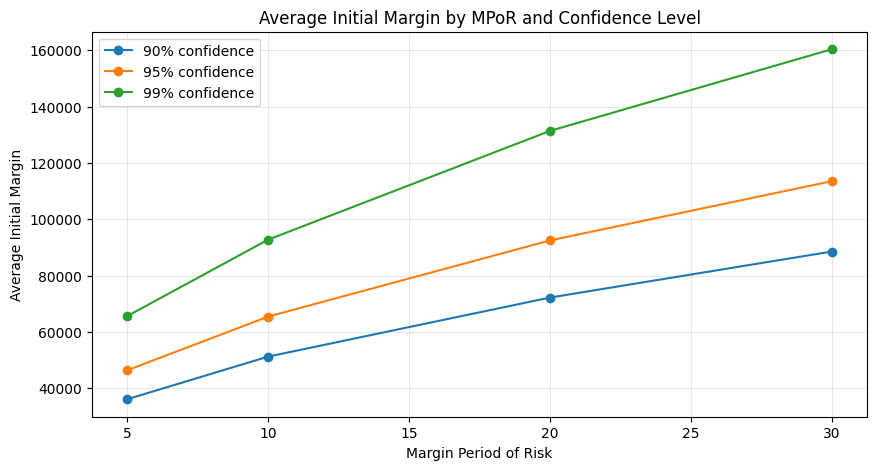

In [ ]:
plt.figure(figsize=(10, 5))

for conf in confidence_levels:
    subset = sensitivity_df[sensitivity_df["Confidence Level"] == conf]
    plt.plot(
        subset["MPoR"],
        subset["Average Initial Margin"],
        marker="o",
        label=f"{int(conf * 100)}% confidence"
    )

plt.title("Average Initial Margin by MPoR and Confidence Level")
plt.xlabel("Margin Period of Risk")
plt.ylabel("Average Initial Margin")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

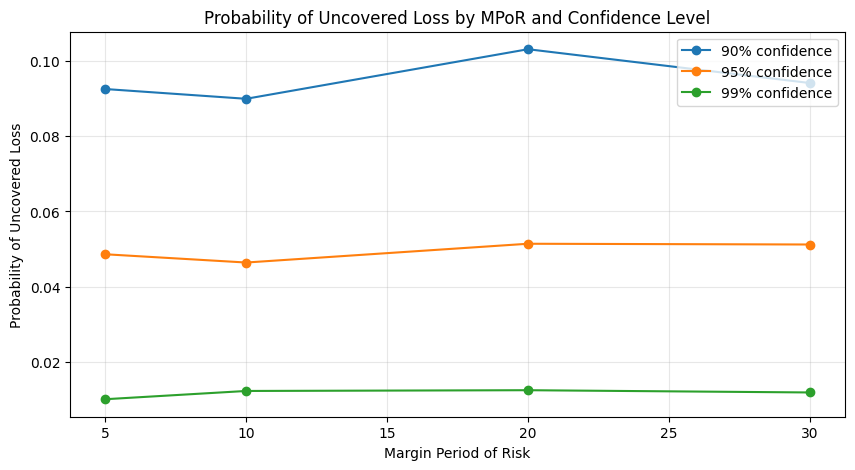

In [ ]:
plt.figure(figsize=(10, 5))

for conf in confidence_levels:
    subset = sensitivity_df[sensitivity_df["Confidence Level"] == conf]
    plt.plot(
        subset["MPoR"],
        subset["Probability of Uncovered Loss"],
        marker="o",
        label=f"{int(conf * 100)}% confidence"
    )

plt.title("Probability of Uncovered Loss by MPoR and Confidence Level")
plt.xlabel("Margin Period of Risk")
plt.ylabel("Probability of Uncovered Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Conclusion

This notebook extends the Excel dashboard by adding a Monte Carlo simulation framework. While the Excel version is useful for understanding one individual scenario, the Python implementation allows us to analyse thousands of possible market paths.

The results show that initial margin significantly reduces residual counterparty risk. Under the base case assumptions, using a 99% confidence level produces a low probability of uncovered loss, close to 1% in the Monte Carlo simulation. This is consistent with the theoretical purpose of a 99% margin buffer: it is designed to cover most, but not all, adverse scenarios.

The sensitivity analysis confirms the main trade-off in margining. Higher confidence levels and longer Margin Periods of Risk increase the required initial margin. This reduces the probability of uncovered loss, but also increases the amount of collateral that must be posted. Therefore, collateral reduces counterparty credit risk, but may create liquidity pressure for market participants.

Overall, the project shows that collateral and margining are powerful risk management tools, but they do not eliminate risk completely. Extreme scenarios can still generate losses beyond the available collateral buffer, which is why stress testing, scenario analysis and robust margin models are essential in OTC derivatives risk management.

## Limitations and Next Steps

This is a simplified educational model. It does not include discounting, netting sets, collateral thresholds, minimum transfer amounts, funding costs, wrong-way risk, legal close-out mechanics or a full SIMM implementation.

Possible extensions include:

- Adding discounting to the forward valuation  
- Modelling collateral thresholds and minimum transfer amounts  
- Adding stressed volatility scenarios  
- Running historical simulations using real market data  
- Comparing the simplified initial margin estimate with a SIMM-style approach  
- Building an interactive dashboard in Python  